# 6. Interpretabilidad con LIME

Este capítulo corresponde a la sección 9.10.4.7 del proyecto. **LIME** (*Local Interpretable Model-agnostic Explanations*; Ribeiro, Singh y Guestrin, 2016) explica una predicción individual en tres pasos:

1. Genera perturbaciones alrededor de la instancia.
2. Obtiene la predicción del modelo para cada perturbación.
3. Ajusta a esas predicciones un modelo lineal ponderado por cercanía, y sus coeficientes indican qué variables empujaron localmente la probabilidad de default hacia arriba o hacia abajo.

Se explica el **modelo con mayor AUC de cada entorno entre los que entregan probabilidades**. LinearSVC queda excluido, porque solo produce valores de decisión.

In [1]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import roc_auc_score

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}
sk_scores, sp_scores = pd.read_parquet(U.SCORES_SK), pd.read_parquet(U.SCORES_SPARK)
prob_models = [m for m in U.MODELS if m != "LinearSVC"]
best = {env: max(prob_models, key=lambda m: roc_auc_score(s[U.TARGET], s[m]))
        for env, s in [("scikit-learn", sk_scores), ("PySpark", sp_scores)]}
print("Modelo explicado en cada entorno:", best)

Modelo explicado en cada entorno: {'scikit-learn': 'GradBoost', 'PySpark': 'GradBoost'}


## 6.1 Espacio de explicación

El modelo recibe 91 columnas: numéricas estandarizadas y dummies. Explicarlo directamente en ese espacio tendría dos problemas:

* las reglas serían ilegibles (por ejemplo, "`int_rate` > 0,63 desviaciones estándar");
* LIME perturbaría por separado cada dummy de una misma variable y crearía préstamos imposibles, como uno a 36 y a 60 meses a la vez.

Por eso LIME trabaja sobre las **26 variables originales**:

* 16 numéricas en su escala real, con los faltantes imputados por la mediana de train;
* 3 indicadores binarios;
* 7 categóricas codificadas como enteros.

La función de predicción que recibe LIME aplica el preprocesamiento ajustado en el capítulo 2 y después el modelo. Las estadísticas que LIME usa para perturbar (cuartiles de las numéricas y frecuencias de las categóricas) se calculan con el conjunto de entrenamiento completo.

In [2]:
data = U.sk_train_test()
prep, raw_train, raw_test = data["prep"], data["raw_train"], data["raw_test"]

LIME_NUM, LIME_BIN, LIME_CAT = U.MODEL_NUM, U.INDICATOR_COLS, U.MODEL_CAT
LIME_COLS = LIME_NUM + LIME_BIN + LIME_CAT
cat_levels = dict(zip(LIME_CAT, [list(c) for c in prep.ohe_.categories_]))

def to_lime(df):
    out = df[LIME_NUM].astype(float).fillna(pd.Series(prep.median_)).copy()
    for c in LIME_BIN:
        out[c] = df[c].astype(float)
    for c in LIME_CAT:
        out[c] = df[c].map({v: i for i, v in enumerate(cat_levels[c])}).astype(float)
    return out[LIME_COLS]

def from_lime(Z):
    df = pd.DataFrame(Z, columns=LIME_COLS)
    for c in LIME_BIN:
        df[c] = df[c].round().astype(float)
    for c in LIME_CAT:
        df[c] = [cat_levels[c][int(round(i))] for i in df[c]]
    return df

L_train, L_test = to_lime(raw_train), to_lime(raw_test)
cat_idx = list(range(len(LIME_NUM), len(LIME_COLS)))
cat_names = {i: (["0", "1"] if c in LIME_BIN else cat_levels[c]) for i, c in zip(cat_idx, LIME_BIN + LIME_CAT)}

explainer = LimeTabularExplainer(
    L_train.to_numpy(), feature_names=LIME_COLS, class_names=["Fully Paid", "Charged Off"],
    categorical_features=cat_idx, categorical_names=cat_names, discretize_continuous=True,
    discretizer="quartile", mode="classification", random_state=U.SEED)
print("Espacio de explicación:", L_train.shape)

Espacio de explicación: (1076248, 26)


## 6.2 Funciones de predicción de cada entorno

* **scikit-learn:** se carga el mejor estimador guardado en el capítulo 3 (`joblib`) y se aplica `SkPreprocessor.transform` seguido de `predict_proba`. Todo ocurre en memoria local.
* **PySpark:** los modelos de Spark no pueden guardarse en este equipo, porque escribir con Spark en Windows requiere `winutils.exe` de Hadoop. Por eso se **reentrena el mejor modelo de Spark con sus mejores hiperparámetros** (sección 4.3) sobre el mismo conjunto de entrenamiento cacheado, sin repetir la validación cruzada. Con la semilla fija, el modelo es el mismo que eligió el `CrossValidator`, y así se comprueba reproduciendo el AUC de prueba. Para cada lote de perturbaciones, la función de predicción de LIME:
  1. crea un DataFrame de Spark (`createDataFrame`) con las 5000 filas;
  2. aplica el `Pipeline` de preprocesamiento y el modelo;
  3. trae las probabilidades al driver con `toPandas()`.

  Lo que se transfiere son las perturbaciones de LIME, no el dataset.

In [3]:
sk_model = joblib.load(U.MODELS_SK_DIR / f"{best['scikit-learn']}.joblib")

def predict_sk(Z):
    return sk_model.predict_proba(prep.transform(from_lime(Z)))

In [4]:
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LogisticRegression, NaiveBayes,
                                       RandomForestClassifier)
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

spark = U.spark_session()
sres = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)   # mismas condiciones que el capítulo 4
classes = {"LogReg": LogisticRegression, "DecisionTree": DecisionTreeClassifier, "RandomForest": RandomForestClassifier,
           "GradBoost": GBTClassifier, "NaiveBayes": NaiveBayes}
tree = dict(maxBins=32, seed=U.SEED, cacheNodeIds=True)
fixed = {"LogReg": dict(elasticNetParam=0.0, standardization=False, maxIter=100),
         "DecisionTree": tree, "RandomForest": tree, "GradBoost": dict(stepSize=0.1, **tree),
         "NaiveBayes": dict(modelType="gaussian")}
name_sp = best["PySpark"]
params_sp = {**fixed[name_sp], **res["PySpark"][name_sp]["best_params"]}

t0 = time.time()
sp_model = classes[name_sp](featuresCol="features", labelCol=U.TARGET, **params_sp).fit(sres["train"])
t_refit = time.time() - t0

check = (sp_model.transform(sres["test"]).select("id", vector_to_array("probability")[1].alias("p")).toPandas()
         .merge(sp_scores[["id", U.TARGET, name_sp]], on="id"))
print(f"{name_sp} reentrenado con {params_sp} en {t_refit:.0f} s")
print(f"AUC test reentrenado = {roc_auc_score(check[U.TARGET], check['p']):.6f} | AUC capítulo 4 = "
      f"{roc_auc_score(check[U.TARGET], check[name_sp]):.6f} | máx |Δp| = {np.abs(check['p'] - check[name_sp]).max():.1e}")

GradBoost reentrenado con {'stepSize': 0.1, 'maxBins': 32, 'seed': 42, 'cacheNodeIds': True, 'maxIter': 100, 'maxDepth': 5} en 483 s


AUC test reentrenado = 0.719463 | AUC capítulo 4 = 0.719463 | máx |Δp| = 0.0e+00


In [5]:
from pyspark.sql.types import DoubleType, StringType, StructField, StructType

spark_schema = StructType([StructField(c, DoubleType()) for c in LIME_NUM + LIME_BIN]
                          + [StructField(c, StringType()) for c in LIME_CAT])
pipeline_sp, bounds_sp = sres["model"], sres["bounds"]
spark_calls = []

def predict_sp(Z):
    t0 = time.time()
    pdf = from_lime(Z)
    sdf = spark.createDataFrame(pdf[LIME_NUM + LIME_BIN + LIME_CAT], schema=spark_schema)
    feats = pipeline_sp.transform(U.spark_clip_log(sdf, bounds_sp))
    p = sp_model.transform(feats).select(vector_to_array("probability")[1].alias("p")).toPandas()["p"].to_numpy()
    spark_calls.append(time.time() - t0)
    return np.column_stack([1 - p, p])

## 6.3 Selección de instancias mal clasificadas

Se eligen dos préstamos del conjunto de prueba que **ambos modelos clasifican mal**, usando el umbral de cada modelo fijado en entrenamiento:

* **Falso negativo:** el préstamo terminó en default, pero los dos modelos le asignaron baja probabilidad. Se toma el caso con la menor probabilidad promedio.
* **Falso positivo:** el préstamo se pagó por completo, pero los dos modelos le asignaron alta probabilidad de default. Se toma el caso con la mayor probabilidad promedio.

Explicar las mismas instancias en ambos entornos permite comparar si los dos modelos se equivocan por las mismas razones.

In [6]:
cmp = (sk_scores[["id", U.TARGET, best["scikit-learn"]]].rename(columns={best["scikit-learn"]: "p_sk"})
       .merge(sp_scores[["id", best["PySpark"]]].rename(columns={best["PySpark"]: "p_sp"}), on="id"))
thr_sk, thr_sp = res["scikit-learn"][best["scikit-learn"]]["threshold"], res["PySpark"][best["PySpark"]]["threshold"]
cmp["pred_sk"], cmp["pred_sp"] = (cmp["p_sk"] >= thr_sk).astype(int), (cmp["p_sp"] >= thr_sp).astype(int)
cmp["p_mean"] = (cmp["p_sk"] + cmp["p_sp"]) / 2
both_wrong = cmp[(cmp["pred_sk"] != cmp[U.TARGET]) & (cmp["pred_sp"] != cmp[U.TARGET])]
fn = both_wrong[both_wrong[U.TARGET] == 1].nsmallest(1, "p_mean")
fp = both_wrong[both_wrong[U.TARGET] == 0].nlargest(1, "p_mean")
chosen = pd.concat([fn.assign(tipo="falso negativo"), fp.assign(tipo="falso positivo")]).set_index("id")
print(f"Préstamos de prueba mal clasificados por ambos modelos: {len(both_wrong):,} de {len(cmp):,}")
print(f"Umbrales: scikit-learn {thr_sk:.4f} | PySpark {thr_sp:.4f}")
chosen[["tipo", U.TARGET, "p_sk", "p_sp"]]

Préstamos de prueba mal clasificados por ambos modelos: 58,983 de 269,062
Umbrales: scikit-learn 0.2959 | PySpark 0.2941


,tipo,default,p_sk,p_sp
id,,,,
36099806,falso negativo,1,0.020898,0.022070
55961482,falso positivo,0,0.793727,0.871252


In [7]:
inst = raw_test.set_index("id").loc[chosen.index, LIME_COLS]
inst.T

id,36099806,55961482
loan_amnt,9600.0,35000.0
int_rate,6.03,28.99
annual_inc,108000.0,100000.0
dti,9.36,7.44
fico_range_high,824.0,784.0
emp_length,10.0,5.0
credit_hist_years,33.585216,3.249829
delinq_2yrs,0.0,0.0
inq_last_6mths,0.0,2.0
open_acc,8.0,8.0


## 6.4 Explicaciones

Para cada instancia y entorno, LIME genera 5000 perturbaciones y muestra las 10 variables con mayor peso local. Las barras naranjas **aumentan** la probabilidad de default y las azules la **reducen**.

In [8]:
N_SAMPLES, N_FEAT = 5000, 10
explanations, lime_times = {}, {}
for loan_id in chosen.index:
    x = L_test.loc[raw_test["id"] == loan_id].to_numpy()[0]
    for env, fn_ in [("scikit-learn", predict_sk), ("PySpark", predict_sp)]:
        t0 = time.time()
        exp = explainer.explain_instance(x, fn_, num_features=N_FEAT, num_samples=N_SAMPLES)
        lime_times[(loan_id, env)] = time.time() - t0
        explanations[(loan_id, env)] = exp

pd.Series({f"{k[0]} | {k[1]}": v for k, v in lime_times.items()}, name="tiempo LIME (s)").round(2)

36099806 | scikit-learn      0.75
36099806 | PySpark         397.14
55961482 | scikit-learn      0.10
55961482 | PySpark         375.33
Name: tiempo LIME (s), dtype: float64

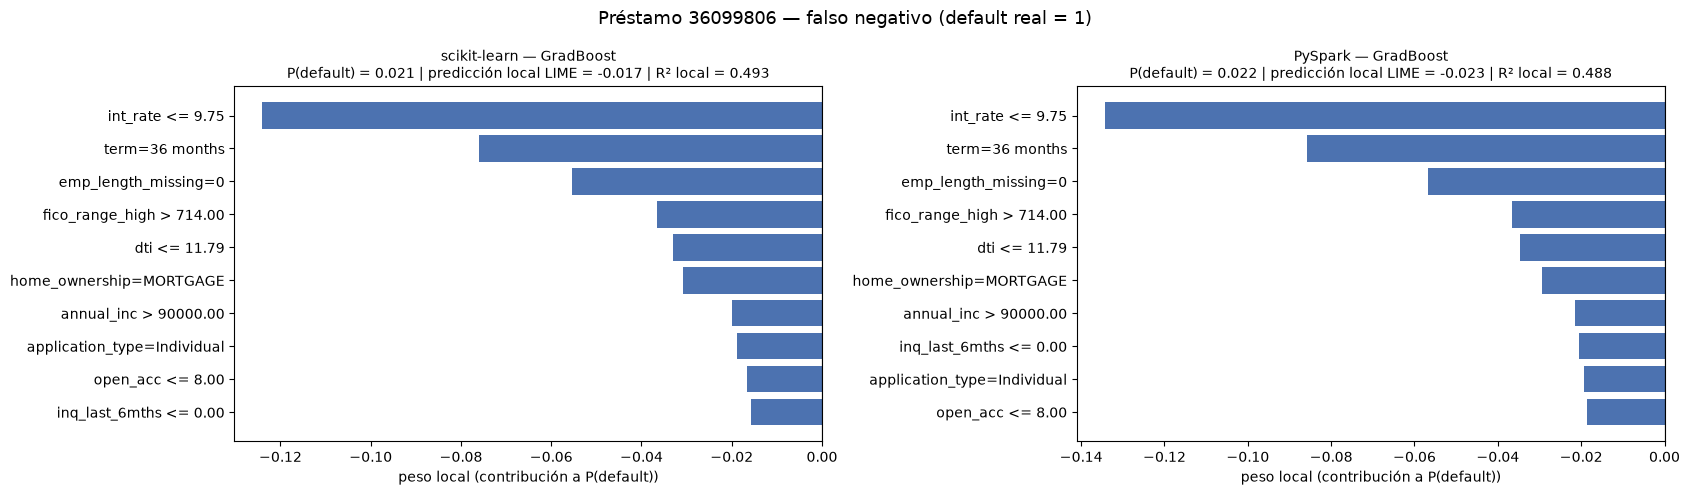

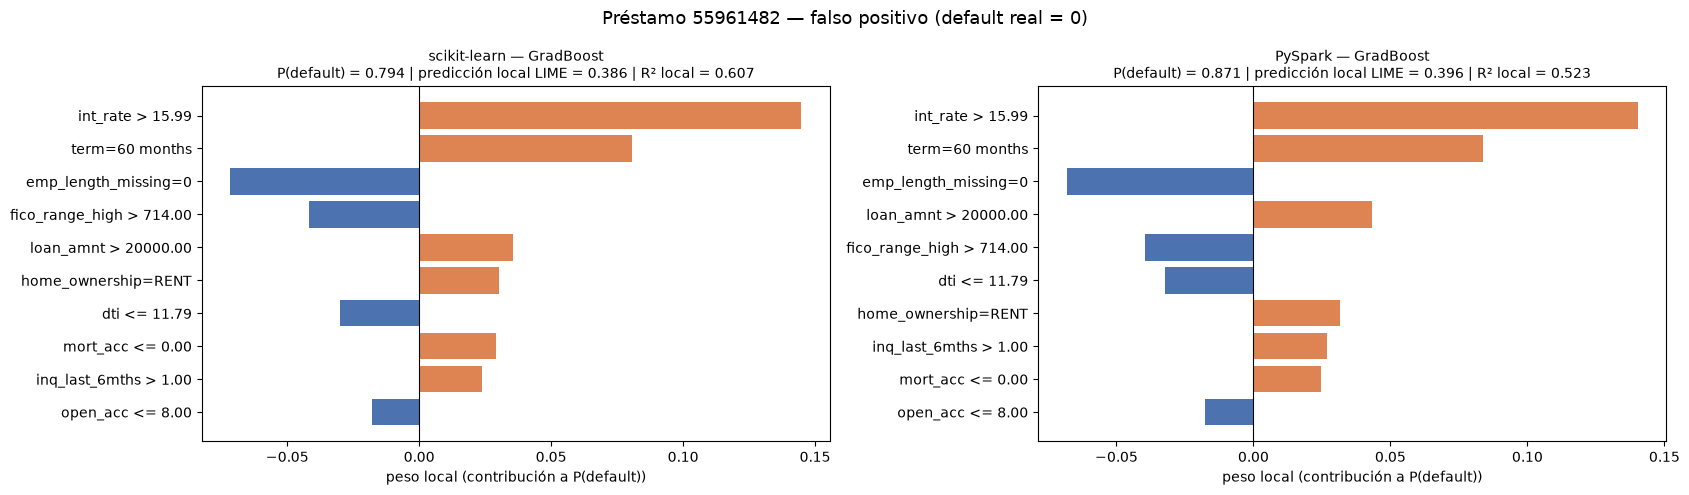

In [9]:
for loan_id in chosen.index:
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    for ax, env in zip(axes, ["scikit-learn", "PySpark"]):
        exp = explanations[(loan_id, env)]
        items = exp.as_list()[::-1]
        ax.barh([k for k, _ in items], [v for _, v in items], color=["#DD8452" if v > 0 else "#4C72B0" for _, v in items])
        ax.axvline(0, c="k", lw=0.8)
        p_model = exp.predict_proba[1]
        ax.set_title(f"{env} — {best[env]}\nP(default) = {p_model:.3f} | predicción local LIME = "
                     f"{exp.local_pred[0]:.3f} | R² local = {exp.score:.3f}", fontsize=10)
        ax.set_xlabel("peso local (contribución a P(default))")
    fig.suptitle(f"Préstamo {loan_id} — {chosen.loc[loan_id, 'tipo']} (default real = {chosen.loc[loan_id, U.TARGET]})",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

In [10]:
rows = []
for (loan_id, env), exp in explanations.items():
    for rank, (feat, w) in enumerate(exp.as_list(), 1):
        rows.append({"préstamo": loan_id, "tipo": chosen.loc[loan_id, "tipo"], "entorno": env, "rango": rank,
                     "condición": feat, "peso": w})
lime_tbl = pd.DataFrame(rows)
lime_tbl.pivot_table(index=["préstamo", "tipo", "rango"], columns="entorno", values="condición", aggfunc="first")

entorno                                            PySpark                 scikit-learn
préstamo tipo           rango                                                          
36099806 falso negativo 1                 int_rate <= 9.75             int_rate <= 9.75
                        2                   term=36 months               term=36 months
                        3             emp_length_missing=0         emp_length_missing=0
                        4         fico_range_high > 714.00     fico_range_high > 714.00
                        5                     dti <= 11.79                 dti <= 11.79
                        6          home_ownership=MORTGAGE      home_ownership=MORTGAGE
                        7            annual_inc > 90000.00        annual_inc > 90000.00
                        8           inq_last_6mths <= 0.00  application_type=Individual
                        9      application_type=Individual             open_acc <= 8.00
                        10                open_acc <= 8.00       inq_last_6mths <= 0.00
55961482 falso positivo 1                 int_rate > 15.99             int_rate > 15.99
                        2                   term=60 months               term=60 months
                        3             emp_length_missing=0         emp_length_missing=0
                        4             loan_amnt > 20000.00     fico_range_high > 714.00
                        5         fico_range_high > 714.00         loan_amnt > 20000.00
                        6                     dti <= 11.79          home_ownership=RENT
                        7              home_ownership=RENT                 dti <= 11.79
                        8            inq_last_6mths > 1.00             mort_acc <= 0.00
                        9                 mort_acc <= 0.00        inq_last_6mths > 1.00
                        10                open_acc <= 8.00             open_acc <= 8.00

In [11]:
def top_vars(exp, k=5):
    # El nombre más largo que aparece en la condición evita confundir emp_length con emp_length_missing.
    return {max((c for c in LIME_COLS if c in cond), key=len) for cond, _ in exp.as_list()[:k]}

agree = pd.DataFrame([{
    "préstamo": loan_id, "tipo": chosen.loc[loan_id, "tipo"],
    "top-5 scikit-learn": sorted(top_vars(explanations[(loan_id, "scikit-learn")])),
    "top-5 PySpark": sorted(top_vars(explanations[(loan_id, "PySpark")])),
    "variables en común (top-5)": len(top_vars(explanations[(loan_id, "scikit-learn")]) & top_vars(explanations[(loan_id, "PySpark")])),
} for loan_id in chosen.index]).set_index("préstamo")
agree

,tipo,top-5 scikit-learn,top-5 PySpark,variables en común (top-5)
préstamo,,,,
36099806,falso negativo,"[dti, emp_length_missing, fico_range_high, int...","[dti, emp_length_missing, fico_range_high, int...",5
55961482,falso positivo,"[emp_length_missing, fico_range_high, int_rate...","[emp_length_missing, fico_range_high, int_rate...",5


### Estabilidad de las explicaciones

LIME es estocástico: las perturbaciones cambian con cada ejecución. Para medir la estabilidad se repite la explicación del falso negativo con el modelo de scikit-learn con 5 semillas distintas y se registra con qué frecuencia cada variable aparece entre las 5 más influyentes. Se usa scikit-learn porque cada llamada en PySpark cuesta varios segundos.

In [12]:
loan_id = chosen.index[0]
x = L_test.loc[raw_test["id"] == loan_id].to_numpy()[0]
counts = {}
for seed in range(5):
    e = LimeTabularExplainer(L_train.to_numpy(), feature_names=LIME_COLS, class_names=["Fully Paid", "Charged Off"],
                             categorical_features=cat_idx, categorical_names=cat_names, discretizer="quartile",
                             random_state=seed).explain_instance(x, predict_sk, num_features=N_FEAT, num_samples=N_SAMPLES)
    for v in top_vars(e):
        counts[v] = counts.get(v, 0) + 1
pd.Series(counts, name="veces en el top-5 (de 5 repeticiones)").sort_values(ascending=False)

emp_length_missing    5
term                  5
int_rate              5
dti                   5
fico_range_high       5
Name: veces en el top-5 (de 5 repeticiones), dtype: int64

## 6.5 Discusión y limitaciones de LIME en entornos distribuidos

El modelo explicado es gradient boosting en ambos entornos. El modelo de Spark reentrenado reproduce exactamente las probabilidades del capítulo 4, con una diferencia máxima nula, lo que confirma que `GBTClassifier` es determinista con semilla y particionado fijos. El resultado central del análisis es que los dos modelos se equivocan por las mismas razones: en ambos préstamos, las cinco condiciones más influyentes coinciden en scikit-learn y en PySpark, en un orden casi idéntico (`int_rate`, `term`, `emp_length_missing`, `fico_range_high` y `dti`). Son precisamente los predictores que el EDA identificó como los más asociados al default, lo que otorga validez sustantiva a las explicaciones.

El falso negativo (préstamo 36099806) recibe en ambos entornos una probabilidad de default de aproximadamente 0,02. Su solicitud describe un perfil de muy bajo riesgo: tasa de 6,03 %, puntaje FICO de 824, plazo de 36 meses, razón deuda/ingreso de 9,4, ingresos de 108 mil dólares, hipoteca y 33 años de historial crediticio. Aun así, el préstamo terminó en default. Las variables disponibles al momento de la originación no pueden anticipar choques posteriores, como la pérdida del empleo, una enfermedad o una separación, de modo que este tipo de error es irreducible con la información disponible y no constituye un defecto del modelo. El falso positivo (préstamo 55961482), con probabilidades de 0,79 a 0,87, presenta el perfil opuesto: tasa de 28,99 %, entre las más altas del conjunto (máximo de 30,99 %), plazo de 60 meses, monto de 35 mil dólares, vivienda en arriendo, ninguna hipoteca y apenas 3,2 años de historial. Sin embargo, fue pagado por completo. En este caso el error se explica sobre todo por `int_rate`, que es la propia evaluación de riesgo de Lending Club: los modelos aprenden en gran medida a reproducir esa evaluación y, con ello, heredan sus errores. La presencia sistemática de `emp_length_missing = 0` entre los factores es coherente con el EDA, donde la ausencia de la antigüedad laboral elevaba el default del 19,5 % al 26,9 %. Por último, al repetir la explicación del falso negativo con cinco semillas, el conjunto de las cinco variables más influyentes no varía, de modo que las explicaciones son estables con 5000 perturbaciones.

Las limitaciones de LIME se agravan en un entorno distribuido. El método opera en memoria local: el explicador necesita las estadísticas del conjunto de entrenamiento (cuartiles y frecuencias), que aquí se calcularon en pandas sobre 1,08 millones de filas y 26 variables, y que con datos más voluminosos exigirían un cálculo distribuido o un muestreo. Además, cada explicación requiere un viaje de ida y vuelta a Spark: crear un DataFrame con las perturbaciones, aplicar el `Pipeline` y el modelo, y traer las probabilidades al driver. Mientras en scikit-learn una explicación tomó entre 0,1 y 0,75 segundos, en PySpark tomó entre 375 y 397 segundos, unas 500 veces más. El volumen de cómputo, de apenas 5000 filas, no explica esa diferencia; la explica el costo fijo de cada trabajo de Spark (planificación, serialización entre Python y la JVM y el reparto del DataFrame en las 400 particiones de `spark.default.parallelism`). Explicar miles de predicciones de este modo sería inviable sin agrupar las perturbaciones de muchas instancias en un único trabajo o recurrir a métodos diseñados para Spark. A ello se suma que, en este equipo, el modelo de Spark no pudo persistirse en disco sin `winutils.exe` y tuvo que reentrenarse (8 minutos), mientras que el de scikit-learn se recuperó directamente con `joblib`.

Por último, LIME tiene limitaciones generales que conviene no perder de vista. Las perturbaciones se generan de forma independiente por variable e ignoran su correlación, de modo que producen préstamos poco plausibles, por ejemplo con una tasa baja y un FICO bajo, cuando la correlación entre ambas variables es de −0,41; la explicación describe entonces el comportamiento del modelo en regiones sin datos. Los resultados dependen, además, de decisiones arbitrarias como la discretización por cuartiles, el ancho del *kernel* y el número de perturbaciones. Y la explicación es local: describe una predicción concreta, no el comportamiento global del modelo ni el mecanismo causal del default.

In [13]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
timings["lime"] = {"refit_pyspark_s": t_refit,
                   "scikit-learn_s": float(np.mean([v for (i, e), v in lime_times.items() if e == "scikit-learn"])),
                   "PySpark_s": float(np.mean([v for (i, e), v in lime_times.items() if e == "PySpark"]))}
(U.DATA_DIR / "timings.json").write_text(json.dumps(timings, indent=2, ensure_ascii=False), encoding="utf-8")
sres["train"].unpersist()
sres["test"].unpersist()
spark.stop()